In [ ]:
import pandas as pd
import random
import numpy as np

import scipy as sp
from scipy import sparse
import sklearn
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
import matplotlib

import time
import pickle
import memory_profiler

%load_ext memory_profiler

from pathlib import Path
import distro

%load_ext watermark

In [ ]:
%load_ext autoreload
%autoreload 2


from text_embeddings_src.legacy.metrics import knn_accuracy, logistic_accuracy
from text_embeddings_src.plotting import (
    plot_label_tags,
    plot_tsne_colors,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures/updated_dataset")
data_path = Path("../data")

In [ ]:
# MANUAL FIX TO PATH ISSUE FROM VSCODE
import text_embeddings_src

nb_path = Path(text_embeddings_src.__path__[0]).parents[0] / Path(
    "scripts"
)
assert nb_path.exists(), "The path does not exist"

variables_path = (nb_path / variables_path).resolve(strict=True)
figures_path = (nb_path / figures_path).resolve(strict=True)
data_path = (nb_path / data_path).resolve(strict=True)

In [ ]:
plt.style.use((nb_path / Path("matplotlib_style.txt")).resolve(strict=True))

In [ ]:
%watermark -a 'Rita González-Márquez' -t -d -tz -u -v -iv -w -m -h -p transformers,openTSNE
print(distro.name(pretty=True))

Author: Rita González-Márquez

Last updated: 2025-02-28 15:23:27CET

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.31.0

transformers: 4.45.2
openTSNE    : 1.0.2

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 4.18.0-553.el8_10.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

Hostname: rgonzalesmarquez_GPU0-llm_gber7

sklearn            : 1.5.2
memory_profiler    : 0.61.0
black              : 24.10.0
pandas             : 2.2.3
jupyter_black      : 0.4.0
scipy              : 1.11.4
matplotlib         : 3.9.2
distro             : 1.9.0
numpy              : 1.26.4
text_embeddings_src: 0.0.0

Watermark: 2.5.0

Ubuntu 24.04 LTS


# Import

In [ ]:
%%time
iclr2024 = pd.read_parquet(
    data_path / "iclr2024.parquet.gzip",
    engine="pyarrow",
)

CPU times: user 261 ms, sys: 89.3 ms, total: 350 ms
Wall time: 266 ms


In [ ]:
iclr2024.keywords = iclr2024.keywords.transform(lambda x: list(x))
iclr2024.scores = iclr2024.scores.transform(lambda x: list(x))

In [ ]:
iclr2024

,index,year,id,title,abstract,authors,decision,scores,keywords,gender-first,gender-last,t-SNE x,t-SNE y
0,0,2017,S1VaB4cex,FractalNet: Ultra-Deep Neural Networks without...,We introduce a design strategy for neural netw...,"Gustav Larsson, Michael Maire, Gregory Shakhna...",Accept (Poster),"[5, 7, 6, 6]",[],male,male,-28.117955,-20.418127
1,1,2017,H1W1UN9gg,Deep Information Propagation,We study the behavior of untrained neural netw...,"Samuel S. Schoenholz, Justin Gilmer, Surya Gan...",Accept (Poster),"[8, 9, 8]","[theory, deep learning]",male,None,-32.466820,-10.791123
2,2,2017,r1GKzP5xx,Recurrent Normalization Propagation,We propose a LSTM parametrization that preser...,"César Laurent, Nicolas Ballas, Pascal Vincent",Invite to Workshop Track,"[4, 6, 6]","[deep learning, optimization]",None,male,3.504240,19.946053
3,3,2017,S1J0E-71l,Surprisal-Driven Feedback in Recurrent Networks,Recurrent neural nets are widely used for pred...,"K, a, m, i, l, , R, o, c, k, i",Reject,"[3, 4, 3]","[unsupervised learning, applications, deep lea...",None,None,4.553473,16.037763
4,4,2017,SJGCiw5gl,Pruning Convolutional Neural Networks for Reso...,We propose a new formulation for pruning convo...,"Pavlo Molchanov, Stephen Tyree, Tero Karras, T...",Accept (Poster),"[6, 7, 9]","[deep learning, transfer learning]",None,male,-25.827705,-37.891772
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24342,7299,2024,1bbPQShCT2,I-PHYRE: Interactive Physical Reasoning,Current evaluation protocols predominantly ass...,,,[],"[intuitive physics, physical reasoning]",None,None,43.137120,44.316133
24343,7300,2024,Ny150AblPu,EXPOSING TEXT-IMAGE INCONSISTENCY USING DIFFUS...,In the battle against widespread online misinf...,,,[],"[mis-contextualization, media forensic]",None,None,59.742172,-22.673627
24344,7301,2024,ZGBOfAQrMl,Video Super-Resolution Transformer with Masked...,"Recently, Vision Transformer has achieved grea...",,,[],"[video super-resolution, adaptive, memory and ...",None,None,57.933273,-3.932825
24345,7302,2024,J2kRjUAOLh,Contrastive Predict-and-Search for Mixed Integ...,Mixed integer linear programs (MILP) are flex...,,,[],[mixed integer programs; contrastive learning],None,None,-11.437999,21.289523


In [ ]:
labels_iclr = np.load(variables_path / "updated_dataset" / "labels_iclr.npy")
colors_iclr = np.load(variables_path / "updated_dataset" / "colors_iclr.npy")

pickle_in = open(
    variables_path / "updated_dataset" / "dict_label_to_color.pkl", "rb"
)
dict_label_to_color = pickle.load(pickle_in)

# Evaluation

## kNN accuracy

### BERT-based models

In [ ]:
model_names = [
    "BERT",
    "MPNet",
    "SBERT",
    "SciBERT",
    "SPECTER",
    "SciNCL",
    "SimCSE",
    "DeCLUTR",
    "DeCLUTR-sci",
    "SPECTER2",
]


model_p"bert-base-uncased"aths = [
    ,
    "microsoft/mpnet-base",
    "sentence-transformers/all-mpnet-base-v2",
    "allenai/scibert_scivocab_uncased",
    "allenai/specter",
    "malteos/scincl",
    "princeton-nlp/unsup-simcse-bert-base-uncased",
    "johngiorgi/declutr-base",
    "johngiorgi/declutr-sci-base",
    "allenai/specter2_base",
]

In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # import
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )

    embedding_cls = np.load(
        variables_path / saving_path / "embedding_abstracts_only_cls.npy"
    )
    embedding_sep = np.load(
        variables_path / saving_path / "embedding_abstracts_only_sep.npy"
    )
    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # print(type(embedding_av))

    # knn acc
    knn_acc = knn_accuracy(
        [
            embedding_av[labels_iclr != "unlabeled"],
            embedding_cls[labels_iclr != "unlabeled"],
            embedding_sep[labels_iclr != "unlabeled"],
        ],
        labels_iclr[labels_iclr != "unlabeled"],
    )
    print(f"{model_name}: {np.array(knn_acc)*100}")

    # save embeddings
    saving_name = Path("knn_accuracy_" + model_name.lower())
    np.save(variables_path / "updated_dataset" / saving_name, knn_acc)

    # print("----------------------------")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


kNN accuracy     [AVG]    [CLS]   [SEP]
BERT: [40.61538462 28.15384615 33.07692308]
MPNet: [37.38461538 31.76923077 36.30769231]
SBERT: [63.30769231 56.76923077 59.84615385]
SciBERT: [44.46153846 21.53846154 28.46153846]
SPECTER: [56.76923077 54.07692308 58.53846154]
SciNCL: [57.         56.76923077 57.76923077]
peak memory: 4360.08 MiB, increment: 3.27 MiB
CPU times: user 49.1 s, sys: 3.67 s, total: 52.7 s
Wall time: 8.02 s


In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # save embeddings
    saving_name = Path("knn_accuracy_" + model_name.lower() + ".npy")
    knn_acc = np.load(variables_path /"updated_dataset" / saving_name)
    print(f"{model_name}: {np.round(np.array(knn_acc)*100,1)}")

    # print("----------------------------")

kNN accuracy     [AVG]    [CLS]   [SEP]
BERT: [40.6 28.2 33.1]
MPNet: [37.4 31.8 36.3]
SBERT: [63.3 56.8 59.8]
SciBERT: [44.5 21.5 28.5]
SPECTER: [56.8 54.1 58.5]
SciNCL: [57.  56.8 57.8]
peak memory: 4353.59 MiB, increment: 0.00 MiB
CPU times: user 386 ms, sys: 99 ms, total: 485 ms
Wall time: 624 ms


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


#### Add new models

In [ ]:
model_names = [
    "SimCSE",
    "DeCLUTR",
    "DeCLUTR-sci",
    "SPECTER2",
]


model_paths = [
    "princeton-nlp/unsup-simcse-bert-base-uncased",
    "johngiorgi/declutr-base",
    "johngiorgi/declutr-sci-base",
    # "allenai/specter2_base",
]
print(model_names)

['SimCSE', 'DeCLUTR', 'DeCLUTR-sci', 'SPECTER2']


In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # import
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )

    embedding_cls = np.load(
        variables_path / saving_path / "embedding_abstracts_only_cls.npy"
    )
    embedding_sep = np.load(
        variables_path / saving_path / "embedding_abstracts_only_sep.npy"
    )
    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # print(type(embedding_av))

    # knn acc
    knn_acc = knn_accuracy(
        [
            embedding_av[labels_iclr != "unlabeled"],
            embedding_cls[labels_iclr != "unlabeled"],
            embedding_sep[labels_iclr != "unlabeled"],
        ],
        labels_iclr[labels_iclr != "unlabeled"],
    )
    print(f"{model_name}: {np.array(knn_acc)*100}")

    # save embeddings
    saving_name = Path("knn_accuracy_" + model_name.lower())
    np.save(variables_path / "updated_dataset" / saving_name, knn_acc)

    # print("----------------------------")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


kNN accuracy     [AVG]    [CLS]   [SEP]
SimCSE: [45.69230769 43.46153846 46.38461538]
DeCLUTR: [50.30769231 45.         34.84615385]
DeCLUTR-sci: [53.46153846 38.76923077 29.23076923]
SPECTER2: [58.23076923 57.15384615 59.69230769]
peak memory: 3156.86 MiB, increment: 160.85 MiB
CPU times: user 29.2 s, sys: 5.49 s, total: 34.6 s
Wall time: 5.8 s


In [ ]:
# new order
model_names = [
    "MPNet",
    "BERT",
    "SciBERT",
    "SimCSE",
    "DeCLUTR",
    "DeCLUTR-sci",
    "SciNCL",
    "SPECTER",
    "SPECTER2",
    "SBERT",
]

In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # save embeddings
    saving_name = Path("knn_accuracy_" + model_name.lower() + ".npy")
    knn_acc = np.load(variables_path / "updated_dataset" / saving_name)
    print(f"{model_name}: {np.round(np.array(knn_acc)*100,1)}")

    # print("----------------------------")

kNN accuracy     [AVG]    [CLS]   [SEP]
MPNet: [37.4 31.8 36.3]
BERT: [40.6 28.2 33.1]
SciBERT: [44.5 21.5 28.5]
SimCSE: [45.7 43.5 46.4]
DeCLUTR: [50.3 45.  34.8]
DeCLUTR-sci: [53.5 38.8 29.2]
SciNCL: [57.  56.8 57.8]
SPECTER: [56.8 54.1 58.5]
SPECTER2: [58.2 57.2 59.7]
SBERT: [63.3 56.8 59.8]
peak memory: 617.73 MiB, increment: 0.00 MiB
CPU times: user 168 ms, sys: 146 ms, total: 314 ms
Wall time: 329 ms


#### Add ST5

In [ ]:
model_names = [
    "ST5",
]


model_paths = [
    "sentence-transformers/sentence-t5-base",
]
print(model_names)

['ST5']


In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # import
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )

    # embedding_cls = np.load(
    #     variables_path / saving_path / "embedding_abstracts_only_cls.npy"
    # )
    # embedding_sep = np.load(
    #     variables_path / saving_path / "embedding_abstracts_only_sep.npy"
    # )
    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # print(type(embedding_av))

    # knn acc
    knn_acc = knn_accuracy(
        embedding_av[labels_iclr != "unlabeled"],
        labels_iclr[labels_iclr != "unlabeled"],
    )
    print(f"{model_name}: {np.array(knn_acc)*100}")

    # save embeddings
    saving_name = Path("knn_accuracy_" + model_name.lower())
    np.save(variables_path / "updated_dataset" / saving_name, knn_acc)

    # print("----------------------------")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


kNN accuracy     [AVG]
ST5: 58.30769230769231
peak memory: 2753.89 MiB, increment: 100.25 MiB
CPU times: user 4.52 s, sys: 5.22 s, total: 9.74 s
Wall time: 918 ms


#### Rebuttal: Add BGE BAAI and other SOTAs

In [ ]:
model_names = [
    # "BGE",
    # "BGE-base",
    "BGE-large",
]


model_paths = [
    # "BAAI/llm-embedder",
    # "BAAI/bge-base-en-v1.5",
    "BAAI/bge-large-en-v1.5",
]

In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # import
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )

    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # print(type(embedding_av))

    # knn acc
    knn_acc = knn_accuracy(
        embedding_av[labels_iclr != "unlabeled"],
        labels_iclr[labels_iclr != "unlabeled"],
    )
    print(f"{model_name}: {np.array(knn_acc)*100}")

    # save embeddings
    saving_name = Path("knn_accuracy_" + model_name.lower())
    np.save(variables_path / "updated_dataset" / saving_name, knn_acc)

    # print("----------------------------")

kNN accuracy     [AVG]
BGE-large: 63.46153846153846
peak memory: 1254.65 MiB, increment: 82.68 MiB
CPU times: user 4.14 s, sys: 5.55 s, total: 9.7 s
Wall time: 745 ms


In [ ]:
BGE-base: 63.30769230769231

### Random BERT

In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG]    [CLS]   [SEP]")
model_name = "random_bert"


# import
saving_path = Path("embeddings_" + model_name.lower()) / Path(
    "updated_dataset"
)

embedding_cls = np.load(
    variables_path / saving_path / "embedding_abstracts_only_cls.npy"
)
embedding_sep = np.load(
    variables_path / saving_path / "embedding_abstracts_only_sep.npy"
)
embedding_av = np.load(
    variables_path / saving_path / "embedding_abstracts_only_av.npy"
)

# print(type(embedding_av))

# knn acc
knn_acc = knn_accuracy(
    [
        embedding_av[labels_iclr != "unlabeled"],
        embedding_cls[labels_iclr != "unlabeled"],
        embedding_sep[labels_iclr != "unlabeled"],
    ],
    labels_iclr[labels_iclr != "unlabeled"],
)
print(f"{model_name}: {np.array(knn_acc)*100}")

# save embeddings
saving_name = Path("knn_accuracy_" + model_name.lower())
np.save(variables_path / "updated_dataset" / saving_name, knn_acc)

# print("----------------------------")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


kNN accuracy     [AVG]    [CLS]   [SEP]
random_bert: [30.84615385 30.53846154  9.46153846]
peak memory: 9033.46 MiB, increment: 5.45 MiB
CPU times: user 9.29 s, sys: 5.1 s, total: 14.4 s
Wall time: 2.04 s


#### Cosine distances

In [ ]:
model_names = [
    "SimCSE",
    "DeCLUTR-sci",
    "SciNCL",
    "SPECTER2",
    "ST5",
    "SBERT",
]


model_paths = [
    "princeton-nlp/unsup-simcse-bert-base-uncased",
    "johngiorgi/declutr-sci-base",
    "malteos/scincl",
    "allenai/specter2_base",
    "sentence-transformers/sentence-t5-base",
    "sentence-transformers/all-mpnet-base-v2",
]
print(model_names)

['SimCSE', 'DeCLUTR-sci', 'SciNCL', 'SPECTER2', 'ST5', 'SBERT']


In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # import
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )
    if model_name != "ST5":
        embedding_cls = np.load(
            variables_path / saving_path / "embedding_abstracts_only_cls.npy"
        )
        embedding_sep = np.load(
            variables_path / saving_path / "embedding_abstracts_only_sep.npy"
        )

    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # print(type(embedding_av))

    # knn acc
    if model_name == "ST5":
        knn_acc = knn_accuracy(
            embedding_av[labels_iclr != "unlabeled"],
            labels_iclr[labels_iclr != "unlabeled"],
            metric="cosine",
        )
    else:
        knn_acc = knn_accuracy(
            [
                embedding_av[labels_iclr != "unlabeled"],
                embedding_cls[labels_iclr != "unlabeled"],
                embedding_sep[labels_iclr != "unlabeled"],
            ],
            labels_iclr[labels_iclr != "unlabeled"],
            metric="cosine",
        )

    print(f"{model_name}: {np.array(knn_acc)*100}")

    # save embeddings
    saving_name = Path("knn_accuracy_cosine_" + model_name.lower())
    np.save(variables_path / "updated_dataset" / saving_name, knn_acc)

    # print("----------------------------")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


kNN accuracy     [AVG]    [CLS]   [SEP]
SimCSE: [45.38461538 43.15384615 46.76923077]
DeCLUTR-sci: [54.07692308 38.84615385 28.84615385]
SciNCL: [56.84615385 56.46153846 57.92307692]
SPECTER2: [57.92307692 57.07692308 59.61538462]
ST5: 58.30769230769231
SBERT: [62.38461538 57.76923077 60.30769231]
peak memory: 3092.23 MiB, increment: 19.64 MiB
CPU times: user 2min 33s, sys: 4min 58s, total: 7min 31s
Wall time: 11.8 s


### TF-IDF

In [ ]:
# save results
tfidf_features = sp.sparse.load_npz(
    variables_path / "updated_dataset" / "tfidf_features.npz"
)

In [ ]:
%%time
%%memit

knn_accuracy_tfidf = knn_accuracy(
    tfidf_features[labels_iclr != "unlabeled"],
    labels_iclr[labels_iclr != "unlabeled"],
)
np.save(
    variables_path / "updated_dataset" / "knn_accuracy_tfidf",
    knn_accuracy_tfidf,
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


peak memory: 4275.61 MiB, increment: 3.04 MiB
CPU times: user 3min 1s, sys: 4.53 s, total: 3min 6s
Wall time: 8.76 s


In [ ]:
print(knn_accuracy_tfidf * 100)

60.0


In [ ]:
%%time
%%memit

knn_accuracy_tfidf = knn_accuracy(
    tfidf_features[labels_iclr != "unlabeled"],
    labels_iclr[labels_iclr != "unlabeled"],
    metric="cosine",
)
np.save(
    variables_path / "updated_dataset" / "knn_accuracy_cosine_tfidf",
    knn_accuracy_tfidf,
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


peak memory: 3268.33 MiB, increment: 119.69 MiB
CPU times: user 3.15 s, sys: 479 ms, total: 3.63 s
Wall time: 1.2 s


In [ ]:
print(knn_accuracy_tfidf * 100)

60.0


### SVD

In [ ]:
svd_data = np.load(variables_path / "updated_dataset" / "svd_data.npy")

In [ ]:
%%time
knn_accuracy_svd = knn_accuracy(
    svd_data[:, :100][labels_iclr != "unlabeled"],
    labels_iclr[labels_iclr != "unlabeled"],
)

np.save(
    variables_path / "updated_dataset" / "knn_accuracy_svd", knn_accuracy_svd
)

CPU times: user 887 ms, sys: 35.8 ms, total: 922 ms
Wall time: 48.5 ms


In [ ]:
print(knn_accuracy_svd * 100)

60.61538461538461


In [ ]:
%%time
knn_accuracy_svd = knn_accuracy(
    svd_data[:, :100][labels_iclr != "unlabeled"],
    labels_iclr[labels_iclr != "unlabeled"],
    metric="cosine",
)

np.save(
    variables_path / "updated_dataset" / "knn_accuracy_cosine_svd",
    knn_accuracy_svd,
)

CPU times: user 9.94 s, sys: 24.2 s, total: 34.1 s
Wall time: 774 ms


In [ ]:
print(knn_accuracy_svd * 100)

62.38461538461538


### L2(SVD)

In [ ]:
svd_data = np.load(variables_path / "updated_dataset" / "svd_data.npy")

In [ ]:
%%time
knn_accuracy_L2_svd = knn_accuracy(
    normalize(svd_data[labels_iclr != "unlabeled"][:, :100], axis=1),
    labels_iclr[labels_iclr != "unlabeled"],
)

np.save(variables_path / "knn_accuracy_L2_svd", knn_accuracy_L2_svd)

CPU times: user 895 ms, sys: 73.3 ms, total: 968 ms
Wall time: 128 ms


In [ ]:
print(knn_accuracy_L2_svd * 100)

62.38461538461538


### RP

In [ ]:
%%time

    knn_accuracy_random_projection = knn_accuracy(
            random_projection[labels_iclr != "unlabeled"],
            labels_iclr[labels_iclr != "unlabeled"],
        )

np.save(variables_path  / "updated_dataset" / "knn_accuracy_random_projection", knn_accuracy_random_projection)

CPU times: user 2.01 s, sys: 40.6 ms, total: 2.05 s
Wall time: 136 ms


In [ ]:
print(knn_accuracy_random_projection * 100)

53.307692307692314


## Linear accuracy

### BERT-based models

In [ ]:
model_names = [
    "BERT",
    "MPNet",
    "SBERT",
    "SciBERT",
    "SPECTER",
    "SciNCL",
]


model_paths = [
    "bert-base-uncased",
    "microsoft/mpnet-base",
    "sentence-transformers/all-mpnet-base-v2",
    "allenai/scibert_scivocab_uncased",
    "allenai/specter",
    "malteos/scincl",
]

In [ ]:
%%time
print("Linear accuracy     [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # load
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )

    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_cls.npy"
    )
    embedding_cls = np.load(
        variables_path / saving_path / "embedding_abstracts_only_sep.npy"
    )
    embedding_sep = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # metric
    accuracy = logistic_accuracy(
        [
            embedding_av[labels_iclr != "unlabeled"],
            embedding_cls[labels_iclr != "unlabeled"],
            embedding_sep[labels_iclr != "unlabeled"],
        ],
        labels_iclr[labels_iclr != "unlabeled"],
    )
    print(f"{model_name}: {np.array(accuracy)*100}")

    # save
    np.save(variables_path / saving_path / "logistic_accuracy", accuracy)

Linear accuracy     [AVG]    [CLS]   [SEP]
BERT: [48.92307692 52.15384615 55.        ]
MPNet: [53.76923077 51.         54.69230769]
SBERT: [57.69230769 57.         60.07692308]
SciBERT: [47.84615385 47.38461538 56.61538462]
SPECTER: [60.         55.84615385 57.61538462]
SciNCL: [61.92307692 58.38461538 58.38461538]
CPU times: user 35min 29s, sys: 1min 10s, total: 36min 39s
Wall time: 34min 25s


### Add new models

In [ ]:
model_names = [
    "SimCSE",
    "DeCLUTR",
    "DeCLUTR-sci",
    "SPECTER2",
]


model_paths = [
    "princeton-nlp/unsup-simcse-bert-base-uncased",
    "johngiorgi/declutr-base",
    "johngiorgi/declutr-sci-base",
    # "allenai/specter2_base",
]

In [ ]:
%%time
print("Linear accuracy     [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # load
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )

    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_cls.npy"
    )
    embedding_cls = np.load(
        variables_path / saving_path / "embedding_abstracts_only_sep.npy"
    )
    embedding_sep = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # metric
    accuracy = logistic_accuracy(
        [
            embedding_av[labels_iclr != "unlabeled"],
            embedding_cls[labels_iclr != "unlabeled"],
            embedding_sep[labels_iclr != "unlabeled"],
        ],
        labels_iclr[labels_iclr != "unlabeled"],
    )
    print(f"{model_name}: {np.array(accuracy)*100}")

    # save
    np.save(variables_path / saving_path / "logistic_accuracy", accuracy)

Linear accuracy     [AVG]    [CLS]   [SEP]
SimCSE: [53.         53.38461538 53.84615385]
DeCLUTR: [53.46153846 48.30769231 51.15384615]
DeCLUTR-sci: [53.92307692 48.69230769 55.76923077]
SPECTER2: [61.30769231 58.84615385 58.84615385]
CPU times: user 24min 15s, sys: 47.8 s, total: 25min 3s
Wall time: 24min 5s


### Random BERT

In [ ]:
%%time
print("Linear accuracy     [AVG]    [CLS]   [SEP]")
model_name = "random_bert"

# load
saving_path = Path("embeddings_" + model_name.lower()) / Path(
    "updated_dataset"
)

embedding_av = np.load(
    variables_path / saving_path / "embedding_abstracts_only_cls.npy"
)
embedding_cls = np.load(
    variables_path / saving_path / "embedding_abstracts_only_sep.npy"
)
embedding_sep = np.load(
    variables_path / saving_path / "embedding_abstracts_only_av.npy"
)

# metric
accuracy = logistic_accuracy(
    [
        embedding_av[labels_iclr != "unlabeled"],
        embedding_cls[labels_iclr != "unlabeled"],
        embedding_sep[labels_iclr != "unlabeled"],
    ],
    labels_iclr[labels_iclr != "unlabeled"],
)
print(f"{model_name}: {np.array(accuracy)*100}")

# save
np.save(variables_path / saving_path / "logistic_accuracy", accuracy)

Linear accuracy     [AVG]    [CLS]   [SEP]
random_bert: [50.92307692 35.61538462 50.76923077]
CPU times: user 5min 4s, sys: 14.5 s, total: 5min 18s
Wall time: 5min 7s


# t-SNE
Compute t-SNE and calculate kNN accuracy in the 2D representation.

## BERT-based models

In [ ]:
%%time
%%memit
print("kNN accuracy          [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # import
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )

    embedding_cls = np.load(
        variables_path / saving_path / "embedding_abstracts_only_cls.npy"
    )
    embedding_sep = np.load(
        variables_path / saving_path / "embedding_abstracts_only_sep.npy"
    )
    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # t-SNE
    A = affinity.Uniform(
        embedding_cls,
        verbose=False,
        method="exact",
        random_state=42,
        k_neighbors=10,
    )
    tsne_cls = TSNE(
        verbose=False, initialization="spectral", random_state=42
    ).fit(affinities=A)

    A = affinity.Uniform(
        embedding_sep,
        verbose=False,
        method="exact",
        random_state=42,
        k_neighbors=10,
    )
    tsne_sep = TSNE(
        verbose=False, initialization="spectral", random_state=42
    ).fit(affinities=A)

    A = affinity.Uniform(
        embedding_av,
        verbose=False,
        method="exact",
        random_state=42,
        k_neighbors=10,
    )
    tsne_av = TSNE(
        verbose=False, initialization="spectral", random_state=42
    ).fit(affinities=A)

    # save
    np.save(variables_path / saving_path / "tsne_cls.npy", tsne_cls)
    np.save(variables_path / saving_path / "tsne_sep.npy", tsne_sep)
    np.save(variables_path / saving_path / "tsne_av.npy", tsne_av)

    # knn acc
    knn_acc = knn_accuracy(
        [
            tsne_av[labels_iclr != "unlabeled"],
            tsne_cls[labels_iclr != "unlabeled"],
            tsne_sep[labels_iclr != "unlabeled"],
        ],
        labels_iclr[labels_iclr != "unlabeled"],
    )
    print(f"t-SNE {model_name}: {np.array(knn_acc)*100}")

    # save embeddings
    saving_name = Path("knn_accuracy_tsne_" + model_name.lower())
    np.save(variables_path / "updated_dataset" / saving_name, knn_acc)

    # print("----------------------------")


KeyboardInterrupt



In [ ]:
%%time
%%memit
print("kNN accuracy     [AVG] [CLS] [SEP]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # save embeddings
    saving_name = Path("knn_accuracy_" + model_name.lower() + ".npy")
    knn_acc = np.load(variables_path / saving_name)
    print(f"{model_name}:          {np.round(np.array(knn_acc)*100,1)}")

    saving_name = Path("knn_accuracy_tsne_" + model_name.lower() + ".npy")
    knn_acc = np.load(variables_path / "updated_dataset" / saving_name)
    print(f"t-SNE {model_name}:    {np.round(np.array(knn_acc)*100,1)}")

    print("----------------------------------")

kNN accuracy     [AVG] [CLS] [SEP]
BERT:          [61.5 50.9 50.8]
t-SNE BERT:    [31.9 19.3 25.1]
----------------------------------
MPNet:          [54.3 53.1 49.5]
t-SNE MPNet:    [27.2 25.2 29.6]
----------------------------------
SBERT:          [77.1 81.2 71.7]
t-SNE SBERT:    [57.8 51.8 55.2]
----------------------------------
SciBERT:          [63.4 36.6 35.9]
t-SNE SciBERT:    [38.1 14.5 20.8]
----------------------------------
SPECTER:          [68.6 77.5 72. ]
t-SNE SPECTER:    [49.8 51.5 53.9]
----------------------------------
SciNCL:          [71.2 77.8 72.4]
t-SNE SciNCL:    [51.3 53.  55.7]
----------------------------------
peak memory: 2776.84 MiB, increment: 0.04 MiB
CPU times: user 246 ms, sys: 102 ms, total: 348 ms
Wall time: 518 ms


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
%%time
%%memit
print("kNN accuracy          [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    saving_name = Path("knn_accuracy_tsne_" + model_name.lower() + ".npy")
    knn_acc = np.load(variables_path / "updated_dataset" / saving_name)
    print(f"t-SNE {model_name}: {np.round(np.array(knn_acc)*100,1)}")

    # print("----------------------------")

kNN accuracy          [AVG]    [CLS]   [SEP]
t-SNE BERT: [31.9 19.3 25.1]
t-SNE MPNet: [27.2 25.2 29.6]
t-SNE SBERT: [57.8 51.8 55.2]
t-SNE SciBERT: [38.1 14.5 20.8]
t-SNE SPECTER: [49.8 51.5 53.9]
t-SNE SciNCL: [51.3 53.  55.7]
peak memory: 2776.85 MiB, increment: 0.00 MiB
CPU times: user 227 ms, sys: 104 ms, total: 331 ms
Wall time: 486 ms


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### Add new models

In [ ]:
model_names = [
    "SimCSE",
    "DeCLUTR",
    "DeCLUTR-sci",
    "SPECTER2",
]


model_paths = [
    "princeton-nlp/unsup-simcse-bert-base-uncased",
    "johngiorgi/declutr-base",
    "johngiorgi/declutr-sci-base",
    # "allenai/specter2_base",
]
print(model_names)

['SimCSE', 'DeCLUTR', 'DeCLUTR-sci', 'SPECTER2']


In [ ]:
%%time
%%memit
print("kNN accuracy          [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):
    # print("Model: ", model_name)

    # import
    saving_path = Path("embeddings_" + model_name.lower()) / Path(
        "updated_dataset"
    )

    embedding_cls = np.load(
        variables_path / saving_path / "embedding_abstracts_only_cls.npy"
    )
    embedding_sep = np.load(
        variables_path / saving_path / "embedding_abstracts_only_sep.npy"
    )
    embedding_av = np.load(
        variables_path / saving_path / "embedding_abstracts_only_av.npy"
    )

    # t-SNE
    A = affinity.Uniform(
        embedding_cls,
        verbose=False,
        method="exact",
        random_state=42,
        k_neighbors=10,
    )
    tsne_cls = TSNE(
        verbose=False, initialization="spectral", random_state=42
    ).fit(affinities=A)

    A = affinity.Uniform(
        embedding_sep,
        verbose=False,
        method="exact",
        random_state=42,
        k_neighbors=10,
    )
    tsne_sep = TSNE(
        verbose=False, initialization="spectral", random_state=42
    ).fit(affinities=A)

    A = affinity.Uniform(
        embedding_av,
        verbose=False,
        method="exact",
        random_state=42,
        k_neighbors=10,
    )
    tsne_av = TSNE(
        verbose=False, initialization="spectral", random_state=42
    ).fit(affinities=A)

    # save
    np.save(variables_path / saving_path / "tsne_cls.npy", tsne_cls)
    np.save(variables_path / saving_path / "tsne_sep.npy", tsne_sep)
    np.save(variables_path / saving_path / "tsne_av.npy", tsne_av)

    # knn acc
    knn_acc = knn_accuracy(
        [
            tsne_av[labels_iclr != "unlabeled"],
            tsne_cls[labels_iclr != "unlabeled"],
            tsne_sep[labels_iclr != "unlabeled"],
        ],
        labels_iclr[labels_iclr != "unlabeled"],
    )
    print(f"t-SNE {model_name}: {np.array(knn_acc)*100}")

    # save embeddings
    saving_name = Path("knn_accuracy_tsne_" + model_name.lower())
    np.save(variables_path / "updated_dataset" / saving_name, knn_acc)

    # print("----------------------------")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


kNN accuracy          [AVG]    [CLS]   [SEP]


/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(
/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(
/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(


t-SNE SimCSE: [40.46153846 36.69230769 38.46153846]


/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(
/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(
/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(


t-SNE DeCLUTR: [45.53846154 37.38461538 24.53846154]


/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(
/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(
/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(


t-SNE DeCLUTR-sci: [49.38461538 32.46153846 23.84615385]


/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(
/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(
/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(


t-SNE SPECTER2: [54.23076923 51.38461538 54.30769231]
peak memory: 3170.73 MiB, increment: 14.02 MiB
CPU times: user 23min 39s, sys: 5min 58s, total: 29min 38s
Wall time: 11min 11s


In [ ]:
%%time
%%memit
print("kNN accuracy          [AVG]    [CLS]   [SEP]")
for i, model_name in enumerate(model_names):

    saving_name = Path("knn_accuracy_tsne_" + model_name.lower() + ".npy")
    knn_acc = np.load(variables_path / "updated_dataset" / saving_name)
    print(f"t-SNE {model_name}: {np.round(np.array(knn_acc)*100,1)}")

    # print("----------------------------")

kNN accuracy          [AVG]    [CLS]   [SEP]
t-SNE SimCSE: [40.5 36.7 38.5]
t-SNE DeCLUTR: [45.5 37.4 24.5]
t-SNE DeCLUTR-sci: [49.4 32.5 23.8]
t-SNE SPECTER2: [54.2 51.4 54.3]
peak memory: 2660.07 MiB, increment: 0.00 MiB
CPU times: user 206 ms, sys: 442 ms, total: 648 ms
Wall time: 485 ms


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## TF-IDF

In [ ]:
# save results
#tfidf_features = sp.sparse.load_npz(variables_path / "tfidf_features.npz")

In [ ]:
%%time
%%memit
A = affinity.Uniform(
    tfidf_features,
    verbose=True,
    method="exact",
    random_state=42,
    k_neighbors=10,
)
tsne_tfidf = TSNE(
    verbose=True, initialization="spectral", random_state=42
).fit(affinities=A)

np.save(variables_path / "updated_dataset" / "tsne_tfidf", tsne_tfidf)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


===> Finding 10 nearest neighbors using exact search using euclidean distance...
   --> Time elapsed: 243.62 seconds
--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, initialization='spectral', random_state=42,
     verbose=True)
--------------------------------------------------------------------------------
===> Calculating spectral initialization...


/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(


   --> Time elapsed: 0.62 seconds
===> Running optimization with exaggeration=12.00, lr=2028.92 for 250 iterations...
Iteration   50, KL divergence 7.4073, 50 iterations in 0.9938 sec
Iteration  100, KL divergence 7.3873, 50 iterations in 0.9474 sec
Iteration  150, KL divergence 7.3777, 50 iterations in 1.0604 sec
Iteration  200, KL divergence 7.3804, 50 iterations in 0.9906 sec
Iteration  250, KL divergence 7.3794, 50 iterations in 1.0405 sec
   --> Time elapsed: 5.03 seconds
===> Running optimization with exaggeration=1.00, lr=24347.00 for 500 iterations...
Iteration   50, KL divergence 4.5737, 50 iterations in 1.0237 sec
Iteration  100, KL divergence 4.3021, 50 iterations in 1.7832 sec
Iteration  150, KL divergence 4.1785, 50 iterations in 2.7014 sec
Iteration  200, KL divergence 4.1070, 50 iterations in 4.1291 sec
Iteration  250, KL divergence 4.0566, 50 iterations in 5.2516 sec
Iteration  300, KL divergence 4.0217, 50 iterations in 5.7286 sec
Iteration  350, KL divergence 3.9939, 

In [ ]:
%%time
%%memit

knn_accuracy_tsne_tfidf = knn_accuracy(
    tsne_tfidf[labels_iclr != "unlabeled"],
    labels_iclr[labels_iclr != "unlabeled"],
)
np.save(
    variables_path / "updated_dataset" / "knn_accuracy_tsne_tfidf",
    knn_accuracy_tsne_tfidf,
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


peak memory: 4265.43 MiB, increment: 10.53 MiB
CPU times: user 2.69 s, sys: 3.74 s, total: 6.43 s
Wall time: 731 ms


In [ ]:
print(knn_accuracy_tsne_tfidf * 100)

50.46153846153846


## SVD

In [ ]:
#svd_data = np.load(variables_path / "svd_data.npy")

In [ ]:
%%time
%%memit
A = affinity.Uniform(
    svd_data[:, :100],
    verbose=True,
    method="exact",
    random_state=42,
    k_neighbors=10,
)
tsne_svd = TSNE(verbose=True, initialization="spectral", random_state=42).fit(
    affinities=A
)

np.save(variables_path / "updated_dataset" / "tsne_svd", tsne_svd)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


===> Finding 10 nearest neighbors using exact search using euclidean distance...
   --> Time elapsed: 0.49 seconds
--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, initialization='spectral', random_state=42,
     verbose=True)
--------------------------------------------------------------------------------
===> Calculating spectral initialization...


/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(


   --> Time elapsed: 0.33 seconds
===> Running optimization with exaggeration=12.00, lr=2028.92 for 250 iterations...
Iteration   50, KL divergence 7.0280, 50 iterations in 1.0913 sec
Iteration  100, KL divergence 7.0042, 50 iterations in 1.0770 sec
Iteration  150, KL divergence 7.0058, 50 iterations in 1.0373 sec
Iteration  200, KL divergence 6.9946, 50 iterations in 0.9768 sec
Iteration  250, KL divergence 7.0005, 50 iterations in 1.0206 sec
   --> Time elapsed: 5.20 seconds
===> Running optimization with exaggeration=1.00, lr=24347.00 for 500 iterations...


Iteration   50, KL divergence 4.3415, 50 iterations in 1.0864 sec
Iteration  100, KL divergence 4.1299, 50 iterations in 1.6510 sec
Iteration  150, KL divergence 4.0398, 50 iterations in 2.7354 sec
Iteration  200, KL divergence 3.9869, 50 iterations in 3.7886 sec
Iteration  250, KL divergence 3.9512, 50 iterations in 4.5590 sec
Iteration  300, KL divergence 3.9262, 50 iterations in 5.5712 sec
Iteration  350, KL divergence 3.9078, 50 iterations in 6.0641 sec
Iteration  400, KL divergence 3.8926, 50 iterations in 6.7225 sec
Iteration  450, KL divergence 3.8809, 50 iterations in 7.5499 sec
Iteration  500, KL divergence 3.8716, 50 iterations in 7.5633 sec
   --> Time elapsed: 47.29 seconds
peak memory: 4312.69 MiB, increment: 47.22 MiB
CPU times: user 1min 9s, sys: 15.4 s, total: 1min 24s
Wall time: 54.1 s


In [ ]:
%%time
%%memit

knn_accuracy_tsne_svd = knn_accuracy(
    tsne_svd[labels_iclr != "unlabeled"],
    labels_iclr[labels_iclr != "unlabeled"],
)
np.save(
    variables_path / "updated_dataset" / "knn_accuracy_tsne_svd",
    knn_accuracy_tsne_svd,
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


peak memory: 4276.17 MiB, increment: 13.54 MiB
CPU times: user 2.8 s, sys: 4.38 s, total: 7.18 s
Wall time: 703 ms


In [ ]:
print(knn_accuracy_tsne_svd * 100)

56.230769230769226


Text(0.5, 1.0, 'SVD (d=100)')

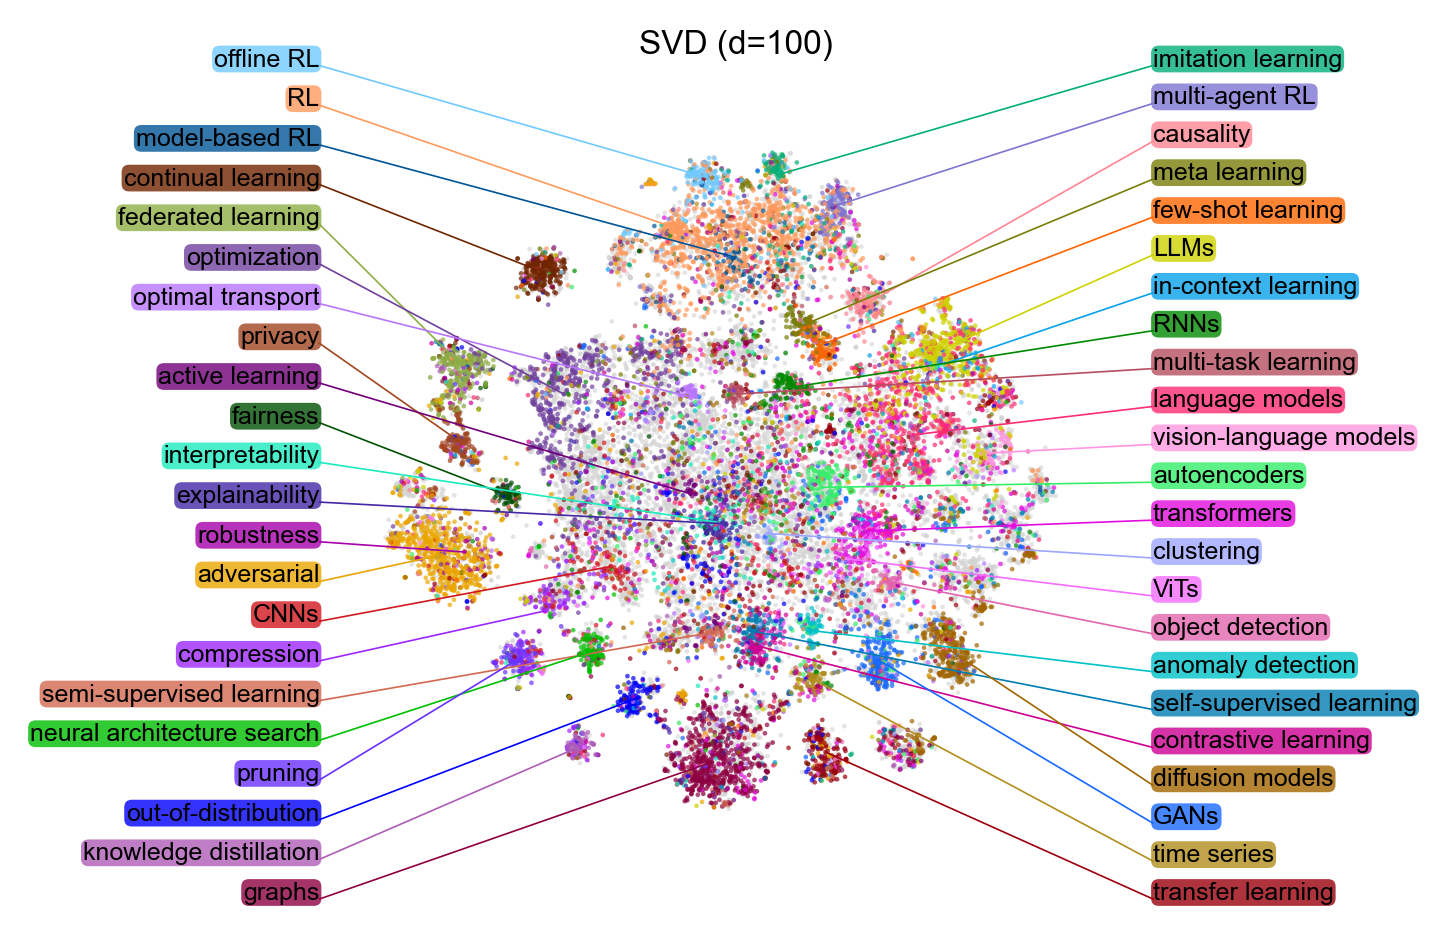

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)
xlim = (-100, 100)
ylim = (-100, 100)
tsne_svd = np.load(variables_path / "updated_dataset" / "tsne_svd.npy")
plot_tsne_colors(tsne_svd, colors_iclr, ax=ax, x_lim=xlim, y_lim=ylim)
plot_label_tags(
    tsne_svd,
    colors_iclr,
    dict_label_to_color,
    x_lim=xlim,
    y_lim=ylim,
    ax=ax,
    subset=False,
    fontsize=6,
    capitalize=False,
)
ax.set_title("SVD (d=100)")
fig.savefig(figures_path / "tsne_iclr_svd_with_tags_v3.png")

## RP

In [ ]:
#random_projection = np.load(variables_path / "random_projection.npy")

In [ ]:
%%time
%%memit
A = affinity.Uniform(
    random_projection,
    verbose=True,
    method="exact",
    random_state=42,
    k_neighbors=10,
)
tsne_random_projection = TSNE(
    verbose=True, initialization="spectral", random_state=42
).fit(affinities=A)

np.save(
    variables_path / "updated_dataset" / "tsne_random_projection",
    tsne_random_projection,
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


===> Finding 10 nearest neighbors using exact search using euclidean distance...
   --> Time elapsed: 1.57 seconds
--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, initialization='spectral', random_state=42,
     verbose=True)
--------------------------------------------------------------------------------
===> Calculating spectral initialization...


/gpfs01/berens/user/rgonzalesmarquez/.local/lib/python3.11/site-packages/openTSNE/affinity.py:1219: FutureWarning: Using `mean` symmetrization, but the default behaviour is going to change to `max` in future versions.
  warnings.warn(


   --> Time elapsed: 0.38 seconds
===> Running optimization with exaggeration=12.00, lr=2028.92 for 250 iterations...
Iteration   50, KL divergence 7.4025, 50 iterations in 0.9845 sec
Iteration  100, KL divergence 7.4177, 50 iterations in 1.0224 sec
Iteration  150, KL divergence 7.4066, 50 iterations in 1.0183 sec
Iteration  200, KL divergence 7.4285, 50 iterations in 0.9567 sec


Iteration  250, KL divergence 7.4271, 50 iterations in 1.0120 sec
   --> Time elapsed: 4.99 seconds
===> Running optimization with exaggeration=1.00, lr=24347.00 for 500 iterations...
Iteration   50, KL divergence 5.8394, 50 iterations in 0.9814 sec
Iteration  100, KL divergence 5.5958, 50 iterations in 1.3037 sec
Iteration  150, KL divergence 5.4887, 50 iterations in 2.0183 sec
Iteration  200, KL divergence 5.4279, 50 iterations in 2.9373 sec
Iteration  250, KL divergence 5.3895, 50 iterations in 3.9087 sec
Iteration  300, KL divergence 5.3618, 50 iterations in 4.7161 sec
Iteration  350, KL divergence 5.3430, 50 iterations in 5.4010 sec
Iteration  400, KL divergence 5.3273, 50 iterations in 6.3682 sec
Iteration  450, KL divergence 5.3151, 50 iterations in 7.2062 sec
Iteration  500, KL divergence 5.3053, 50 iterations in 8.5313 sec
   --> Time elapsed: 43.37 seconds
peak memory: 4319.27 MiB, increment: 36.30 MiB
CPU times: user 1min 36s, sys: 21.8 s, total: 1min 58s
Wall time: 51.1 s


In [ ]:
%%time
%%memit

knn_accuracy_tsne_random_projection = knn_accuracy(
    tsne_random_projection[labels_iclr != "unlabeled"],
    labels_iclr[labels_iclr != "unlabeled"],
)
np.save(
    variables_path / "updated_dataset" / "knn_accuracy_tsne_random_projection",
    knn_accuracy_tsne_random_projection,
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


peak memory: 4279.49 MiB, increment: 14.54 MiB
CPU times: user 2.58 s, sys: 2.72 s, total: 5.3 s
Wall time: 705 ms


In [ ]:
print(knn_accuracy_tsne_random_projection * 100)

43.230769230769226


## Plot

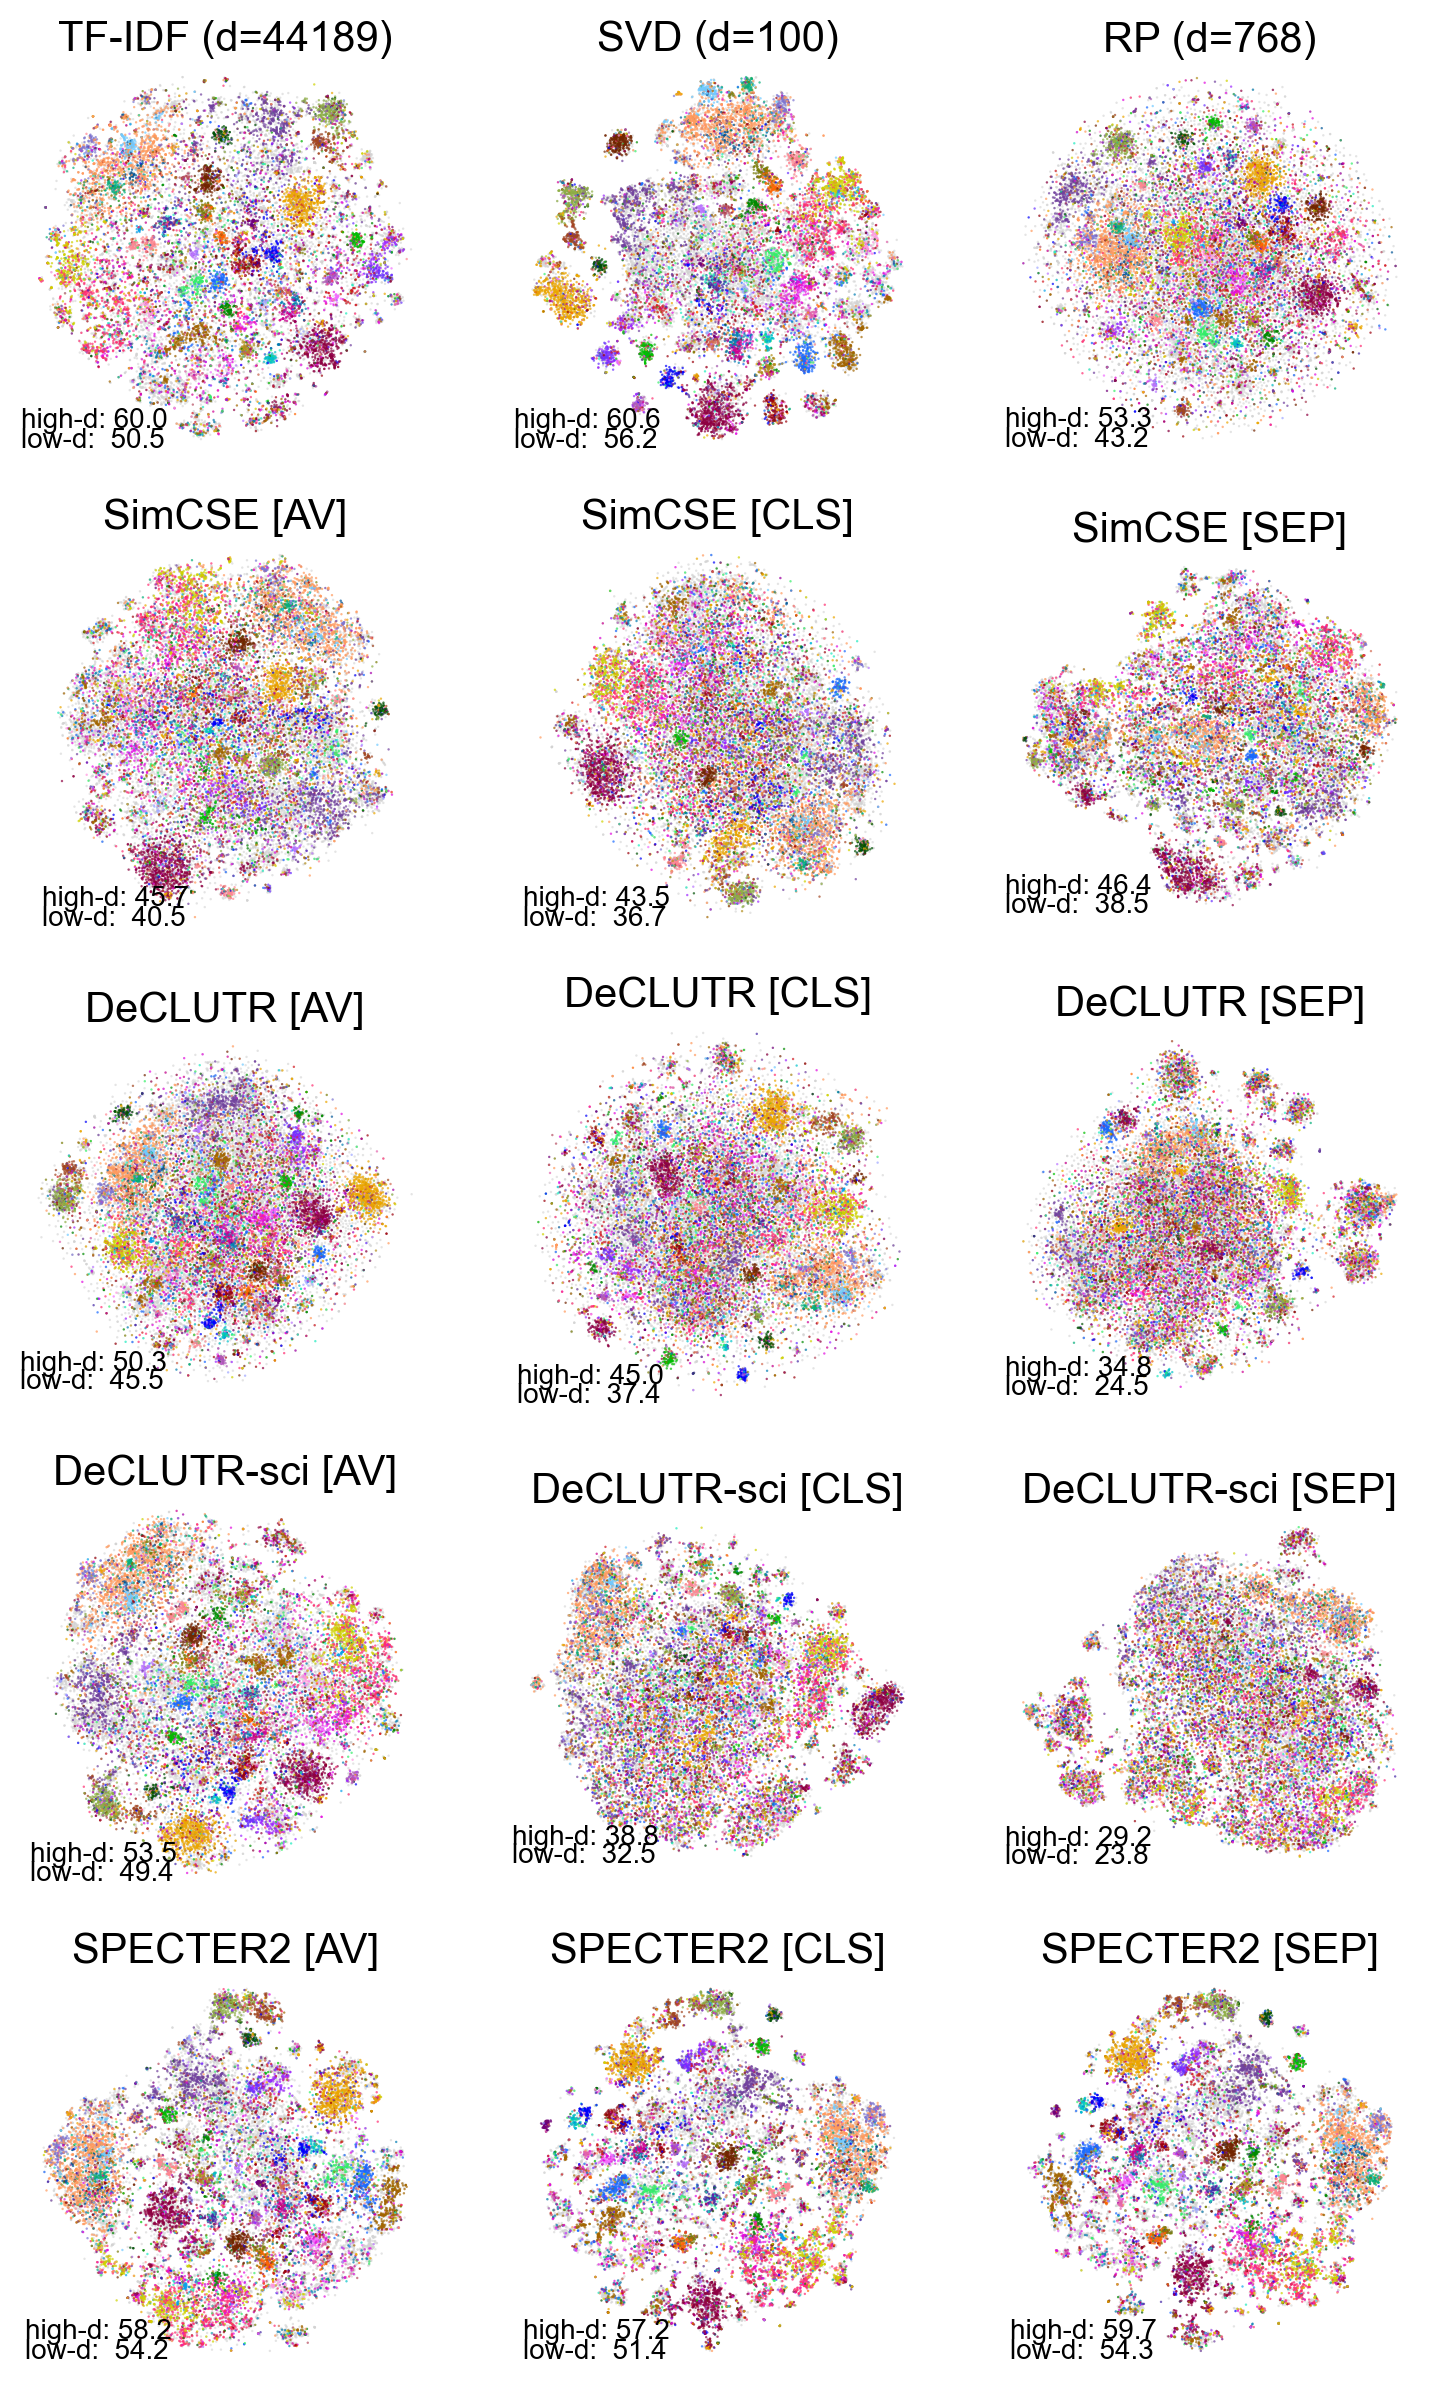

In [ ]:
fig, axs = plt.subplots(
    len(model_names) + 1, 3, figsize=(9, 3 * (len(model_names) + 1)), dpi=200
)
rep = ["av", "cls", "sep"]
for i in range(len(model_names) + 1):
    for j in range(3):
        if (i == 0) & (j == 0):
            # load
            ## tsnes
            tsne_tfidf = np.load(
                variables_path / "updated_dataset" / "tsne_tfidf.npy"
            )
            tsne_svd = np.load(
                variables_path / "updated_dataset" / "tsne_svd.npy"
            )
            tsne_random_projection = np.load(
                variables_path
                / "updated_dataset"
                / "tsne_random_projection.npy"
            )

            ## accuracies
            knn_accuracy_tfidf = np.load(
                variables_path / "updated_dataset" / "knn_accuracy_tfidf.npy"
            )
            knn_accuracy_svd = np.load(
                variables_path / "updated_dataset" / "knn_accuracy_svd.npy"
            )
            knn_accuracy_random_projection = np.load(
                variables_path
                / "updated_dataset"
                / "knn_accuracy_random_projection.npy"
            )

            knn_accuracy_tsne_tfidf = np.load(
                variables_path
                / "updated_dataset"
                / "knn_accuracy_tsne_tfidf.npy"
            )
            knn_accuracy_tsne_svd = np.load(
                variables_path
                / "updated_dataset"
                / "knn_accuracy_tsne_svd.npy"
            )
            knn_accuracy_tsne_random_projection = np.load(
                variables_path
                / "updated_dataset"
                / "knn_accuracy_tsne_random_projection.npy"
            )

            plot_tsne_colors(
                tsne_tfidf, colors_iclr, ax=axs[i, 0], plot_type="subplot_3"
            )
            axs[i, 0].set_title(f"TF-IDF (d=44189)", fontsize=15)

            axs[i, 0].text(
                0,
                0.06,
                f"high-d: {knn_accuracy_tfidf*100:.1f}",
                transform=axs[i, 0].transAxes,
                va="bottom",
                ha="left",
                size=10,
            )
            axs[i, 0].text(
                0,
                0.01,
                f"low-d:  {knn_accuracy_tsne_tfidf*100:.1f}",
                transform=axs[i, 0].transAxes,
                va="bottom",
                ha="left",
                size=10,
            )

            plot_tsne_colors(
                tsne_svd,
                colors_iclr,
                ax=axs[i, 1],
                plot_type="subplot_3",
            )
            axs[i, 1].set_title("SVD (d=100)", fontsize=15)
            axs[i, 1].text(
                0,
                0.06,
                f"high-d: {knn_accuracy_svd*100:.1f}",
                transform=axs[i, 1].transAxes,
                va="bottom",
                ha="left",
                size=10,
            )
            axs[i, 1].text(
                0,
                0.01,
                f"low-d:  {knn_accuracy_tsne_svd*100:.1f}",
                transform=axs[i, 1].transAxes,
                va="bottom",
                ha="left",
                size=10,
            )

            plot_tsne_colors(
                tsne_random_projection,
                colors_iclr,
                ax=axs[i, 2],
                plot_type="subplot_3",
            )
            axs[i, 2].set_title("RP (d=768)", fontsize=15)
            axs[i, 2].text(
                0,
                0.06,
                f"high-d: {knn_accuracy_random_projection*100:.1f}",
                transform=axs[i, 2].transAxes,
                va="bottom",
                ha="left",
                size=10,
            )
            axs[i, 2].text(
                0,
                0.01,
                f"low-d:  {knn_accuracy_tsne_random_projection*100:.1f}",
                transform=axs[i, 2].transAxes,
                va="bottom",
                ha="left",
                size=10,
            )
        elif i != 0:
            # break
            # load
            ## tsnes
            saving_path = Path(
                "embeddings_" + model_names[i - 1].lower()
            ) / Path("updated_dataset")
            tsne_name = "tsne_" + rep[j] + ".npy"
            tsne = np.load(variables_path / saving_path / tsne_name)

            ## accuracies
            saving_name = Path(
                "knn_accuracy_" + model_names[i - 1].lower() + ".npy"
            )
            knn_acc_highd = np.load(
                variables_path / "updated_dataset" / saving_name
            )

            saving_name = Path(
                "knn_accuracy_tsne_" + model_names[i - 1].lower() + ".npy"
            )
            knn_acc_lowd = np.load(
                variables_path / "updated_dataset" / saving_name
            )

            # plot
            plot_tsne_colors(
                tsne, colors_iclr, ax=axs[i, j], plot_type="subplot_3"
            )
            title = model_names[i - 1] + " [" + rep[j].upper() + "]"
            axs[i, j].set_title(title, fontsize=15)
            axs[i, j].text(
                0,
                0.06,
                f"high-d: {knn_acc_highd[j]*100:.1f}",
                transform=axs[i, j].transAxes,
                va="bottom",
                ha="left",
                size=10,
            )
            axs[i, j].text(
                0,
                0.01,
                f"low-d:  {knn_acc_lowd[j]*100:.1f}",
                transform=axs[i, j].transAxes,
                va="bottom",
                ha="left",
                size=10,
            )

fig.savefig(figures_path / "tsne_embeddings_iclr_with_knn_accs_v2.png")